In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageOps
import pandas as pd
from sklearn.cluster import KMeans

In [2]:
cale = "./data/Soil Types"
os.listdir(cale)

['Black Soil', 'Cinder Soil', 'Laterite Soil', 'Peat Soil', 'Yellow Soil']

In [3]:
fisiere = []
labels = []
valid_extensions = ('.jpg')

for root, dirs, files in os.walk(cale):
    print(root, "consumes", end=" ")
    label = os.path.basename(root)
    for name in files:
        cale_fisier = os.path.abspath(os.path.join(root, name))
        if os.path.splitext(cale_fisier)[1].lower()in valid_extensions:
            fisiere.append(cale_fisier)
            labels.append(label)

if '__pycache__' in dirs:
        dirs.remove('__pycache__')  # don't visit __pycache__ directories

./data/Soil Types consumes ./data/Soil Types\Black Soil consumes ./data/Soil Types\Cinder Soil consumes ./data/Soil Types\Laterite Soil consumes ./data/Soil Types\Peat Soil consumes ./data/Soil Types\Yellow Soil consumes 

In [4]:
nr_files = len(fisiere)
print(f'setul de date are {nr_files} fișiere' )

setul de date are 156 fișiere


Dimensiunea imaginii:  (160, 144, 3)
Tip date pixel:  uint8
Nr benzi:  3
Val minima:  0
Val maxima:  255


(<Figure size 640x480 with 1 Axes>,
 <matplotlib.image.AxesImage at 0x22d40116960>)

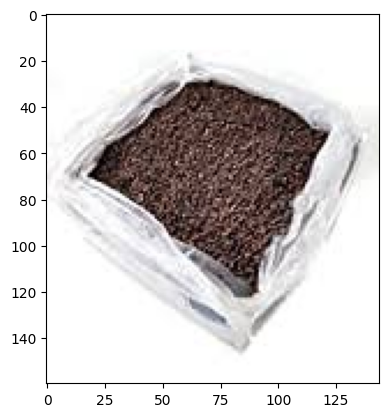

In [5]:
# citirea imaginii și convertirea ei în array
img = Image.open(fisiere[50])
img = np.array(img)

# carateristicile imaginii
print("Dimensiunea imaginii: ", img.shape)
print("Tip date pixel: ", img.dtype)
print("Nr benzi: ", img.shape[2])
print("Val minima: ", np.min(img))
print("Val maxima: ", np.max(img))
# afisarea imaginii
plt.figure(),plt.imshow(img)

In [6]:
def standardizare(path, size=(128, 128)):
    img = Image.open(path)

    # corectie orientare (pt siguranta)
    img = ImageOps.exif_transpose(img)

    # asigurare fromat RGB
    img = img.convert("RGB")

    # redimensionare
    img = img.resize(size)

    # convertire in array si normalizare
    img = np.array(img)
    img = np.float32(img)
    img /= 255

    return img

<class 'numpy.dtypes.Float32DType'>
0.24705882


(<Figure size 640x480 with 1 Axes>,
 <matplotlib.image.AxesImage at 0x22d40173320>)

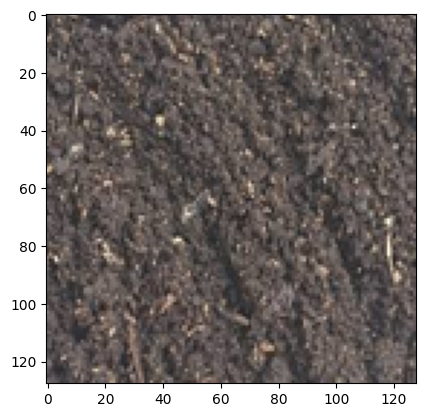

In [7]:
test = standardizare(fisiere[0])
print(type(test.dtype))
print (test[80][80][1])
plt.figure(),plt.imshow(test)

In [8]:
# 1. functie pentru obtinerea cuvintelor dintr-o imagine
def extragere_cuvinte(img, patch_size):
    H, W, C = img.shape
    cuvinte = []
    for i in range (0, H - patch_size + 1, patch_size):
      for j in range (0, W - patch_size + 1, patch_size):
        patch = img[i:i+patch_size, j:j+patch_size, :]
        cuvinte.append(patch.flatten())
    return cuvinte

In [9]:
# 2. funcție pentru obtinerea vocabular
from sklearn.cluster import KMeans
def obtinere_vocabular(cuvinte_set, vocab_size = 100):
    if (len(cuvinte_set) < vocab_size):
      raise ValueError("Not enough words!")

    kmeans = KMeans(n_clusters = vocab_size, random_state = 42, n_init = 1)
    kmeans.fit(cuvinte_set)


    vocabular = kmeans.cluster_centers_
    return kmeans, vocabular

In [11]:
# 3. funcție pentru determinarea descriptorului unei imagini

def bow4image(cuvinte_img, kmeans, vocab_size):

    clustere = kmeans.predict(cuvinte_img)
    histograma = np.bincount(clustere, minlength = vocab_size)
    histograma = histograma / np.sum(histograma)
    return histograma

In [12]:
# 1. obtinerea cuvintelor pentru intregul set de date si asocierea fiecarui cuvant cu indexul căii imaginii
cuvinte_set = []
index_imagini = [0]

for index, path in enumerate(fisiere):
  img = standardizare(path)
  cuvinte = extragere_cuvinte(img, 3)
  index_imagini.append((index+1)*len(cuvinte))
  cuvinte_set.extend(cuvinte)

print(np.array(cuvinte_set).shape)

(275184, 27)


In [13]:
# 2. obtinerea vocabularului
kmeans, vocab = obtinere_vocabular(cuvinte_set, vocab_size = 100)

print('cuvinte din set: ', len(cuvinte_set))
print('cuvinte din set: ', index_imagini[-1])


cuvinte din set:  275184
cuvinte din set:  275184


(<Figure size 640x480 with 1 Axes>,
 [<matplotlib.lines.Line2D at 0x22d4236e3c0>])

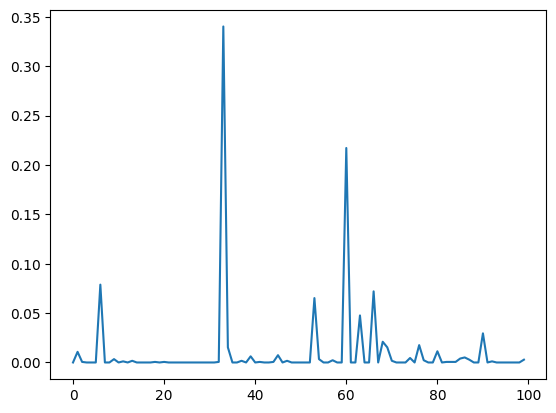

In [14]:
# 3 determinarea setului de descriptori (histograme de cuvinte) pt intregul set de date


# pt o singura imagine
cuvinte = cuvinte_set[index_imagini[index-1]:index_imagini[index]]
bow_vector = bow4image(cuvinte, kmeans, 100)


plt.figure(),plt.plot(bow_vector)



In [15]:
data = []

num_images = len(index_imagini) - 1

for i in range(num_images):
    start = index_imagini[i]
    end = index_imagini[i + 1]

    cuvinte = cuvinte_set[start:end]
    bow_vector = bow4image(cuvinte, kmeans, 100)

    data.append(bow_vector)

data = np.array(data)

print(data.shape)

(156, 100)


In [16]:
from sklearn.model_selection import train_test_split
from collections import Counter

label_dict = {'Black Soil': 0,
 'Cinder Soil': 1,
 'Laterite Soil': 2,
 'Peat Soil': 3,
 'Yellow Soil': 4,
}

reverse_label_dict = {v: k for k, v in label_dict.items()}

numeric_labels = []
for i, label in enumerate(labels):
  numeric_labels.append(label_dict[label])

data_train, data_test, labels_train, labels_test = train_test_split(
    data, numeric_labels, test_size=0.3, random_state=42, shuffle=True, stratify=numeric_labels
)

def print_class_distribution(labels, split_name):
    counts = Counter(labels)
    print(f"\n{split_name} set ({len(labels)} images total):")
    for class_id, count in sorted(counts.items()):
        print(f"  {reverse_label_dict[class_id]}: {count} images")

print_class_distribution(labels_train, "Train")
print_class_distribution(labels_test, "Test")


Train set (109 images total):
  Black Soil: 26 images
  Cinder Soil: 21 images
  Laterite Soil: 21 images
  Peat Soil: 21 images
  Yellow Soil: 20 images

Test set (47 images total):
  Black Soil: 11 images
  Cinder Soil: 9 images
  Laterite Soil: 9 images
  Peat Soil: 9 images
  Yellow Soil: 9 images


In [17]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100)
rf.fit(data_train, labels_train)

labels_pred_rf = rf.predict(data_test)

accuracy = np.mean(labels_pred_rf == labels_test)
print("RF Accuracy:", accuracy)

RF Accuracy: 0.8085106382978723


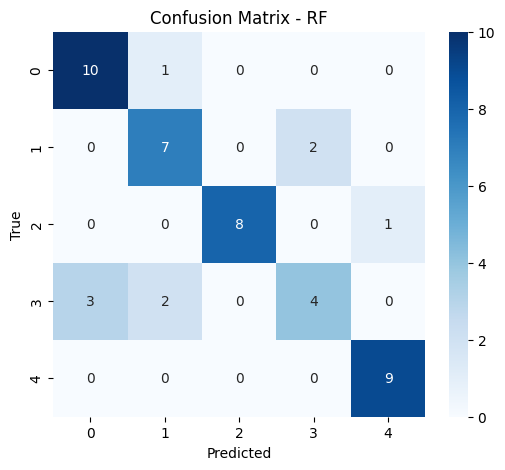

Classification Report:

              precision    recall  f1-score   support

           0       0.77      0.91      0.83        11
           1       0.70      0.78      0.74         9
           2       1.00      0.89      0.94         9
           3       0.67      0.44      0.53         9
           4       0.90      1.00      0.95         9

    accuracy                           0.81        47
   macro avg       0.81      0.80      0.80        47
weighted avg       0.81      0.81      0.80        47



In [18]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

cm = confusion_matrix(labels_test, labels_pred_rf)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - RF")
plt.show()

print("Classification Report:\n")
print(classification_report(labels_test, labels_pred_rf, zero_division=0))